In [49]:
#!/bin/bash
!curl -L -o palmer-archipelago-antarctica-penguin-data.zip\
  https://www.kaggle.com/api/v1/datasets/download/parulpandey/palmer-archipelago-antarctica-penguin-data

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 11558  100 11558    0     0  30095      0 --:--:-- --:--:-- --:--:-- 30095


In [50]:
!unzip /content/palmer-archipelago-antarctica-penguin-data.zip

Archive:  /content/palmer-archipelago-antarctica-penguin-data.zip
replace penguins_lter.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [52]:
df = pd.read_csv('/content/penguins_size.csv')

In [53]:
df

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,FEMALE
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,MALE
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,FEMALE


In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   culmen_length_mm   342 non-null    float64
 3   culmen_depth_mm    342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                334 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [55]:
df.isnull().sum()

,0
species,0
island,0
culmen_length_mm,2
culmen_depth_mm,2
flipper_length_mm,2
body_mass_g,2
sex,10


In [56]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
culmen_length_mm,342.0,43.921930,5.459584,32.1,39.225,44.45,48.5,59.6
culmen_depth_mm,342.0,17.151170,1.974793,13.1,15.600,17.30,18.7,21.5
flipper_length_mm,342.0,200.915205,14.061714,172.0,190.000,197.00,213.0,231.0
body_mass_g,342.0,4201.754386,801.954536,2700.0,3550.000,4050.00,4750.0,6300.0


In [57]:
df['island'].value_counts()

,count
island,
Biscoe,168
Dream,124
Torgersen,52


In [58]:
df['sex'].value_counts(dropna=False)

,count
sex,
MALE,168
FEMALE,165
NaN,10
.,1


In [59]:
df = df.dropna(subset=['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g'])

In [60]:
df = df.dropna(subset=['sex'])

In [61]:
df.isnull().sum().sum()

np.int64(0)

In [62]:
df = df[df['sex'] != '.']

In [63]:
df['sex'].value_counts()

,count
sex,
MALE,168
FEMALE,165


In [64]:
df.shape

(333, 7)

In [65]:
from sklearn.preprocessing import StandardScaler

In [66]:
X = df.drop(columns=['species'])

In [67]:
X_encoded = pd.get_dummies(X, columns=['island', 'sex'], drop_first=True)

In [68]:
X_encoded.head(3)

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,island_Dream,island_Torgersen,sex_MALE
0,39.1,18.7,181.0,3750.0,False,True,True
1,39.5,17.4,186.0,3800.0,False,True,False
2,40.3,18.0,195.0,3250.0,False,True,False


In [69]:
scaler = StandardScaler()

In [70]:
X_scaled = scaler.fit_transform(X_encoded)

In [72]:
X_scaled_df = pd.DataFrame(X_scaled, columns=X_encoded.columns)

In [73]:
X_scaled_df.head()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,island_Dream,island_Torgersen,sex_MALE
0,-0.896042,0.780732,-1.426752,-0.568475,-0.76532,2.466801,0.991031
1,-0.822788,0.119584,-1.069474,-0.506286,-0.76532,2.466801,-1.009050
2,-0.676280,0.424729,-0.426373,-1.190361,-0.76532,2.466801,-1.009050
3,-1.335566,1.085877,-0.569284,-0.941606,-0.76532,2.466801,-1.009050
4,-0.859415,1.747026,-0.783651,-0.692852,-0.76532,2.466801,0.991031


In [74]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [81]:
inertia_values = []
silhouette_scores = []
k_range = range(2, 11)

kmeans_1 = KMeans(n_clusters=1, random_state=42, n_init=10)
kmeans_1.fit(X_scaled)
all_inertia = [kmeans_1.inertia_]

for k in k_range:
  kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
  kmeans.fit(X_scaled)

  inertia_values.append(kmeans.inertia_)
  all_inertia.append(kmeans.inertia_)

  score = silhouette_score(X_scaled, kmeans.labels_)
  silhouette_scores.append(score)

  print(f"K = {k} -> {score}")

K = 2 -> 0.3883760816847586
K = 3 -> 0.4357687088322124
K = 4 -> 0.42774362625759754
K = 5 -> 0.4674396949948242
K = 6 -> 0.4845033867808178
K = 7 -> 0.4916305259338159
K = 8 -> 0.5142275638324951
K = 9 -> 0.5410225059567223
K = 10 -> 0.5540607604044122


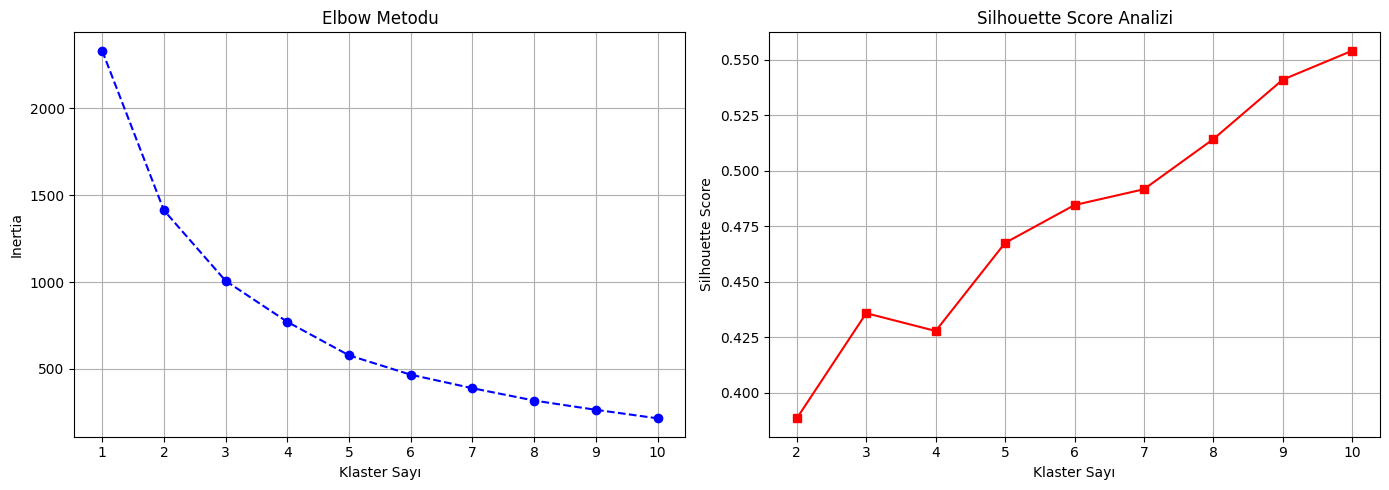

In [82]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(range(1, 11), all_inertia, marker='o', color='b', linestyle='--')
ax1.set_title('Elbow Metodu')
ax1.set_xlabel('Klaster Sayı')
ax1.set_ylabel('Inertia')
ax1.set_xticks(range(1, 11))
ax1.grid(True)

ax2.plot(k_range, silhouette_scores, marker='s', color='r', linestyle='-')
ax2.set_title('Silhouette Score Analizi')
ax2.set_xlabel('Klaster Sayı')
ax2.set_ylabel('Silhouette Score')
ax2.set_xticks(k_range)
ax2.grid(True)

plt.tight_layout()
plt.show()

In [85]:
optimal_k = 3
kmeans_model = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)

cluster_labels = kmeans_model.fit_predict(X_scaled)

df['cluster_label'] = cluster_labels

print(df['cluster_label'].value_counts())

cluster_label
2    167
1    119
0     47
Name: count, dtype: int64


In [87]:
df.head()

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex,cluster_label
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE,0
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE,0
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE,0
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE,0
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,MALE,0


In [88]:
from sklearn.decomposition import PCA

In [91]:
pca = PCA(n_components=2)

pca_features = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(data=pca_features, columns=['PCA1', 'PCA2'])

df_pca['Cluster'] = cluster_labels

In [93]:
pc1 = pca_features[:, 0]
pc2 = pca_features[:, 1]

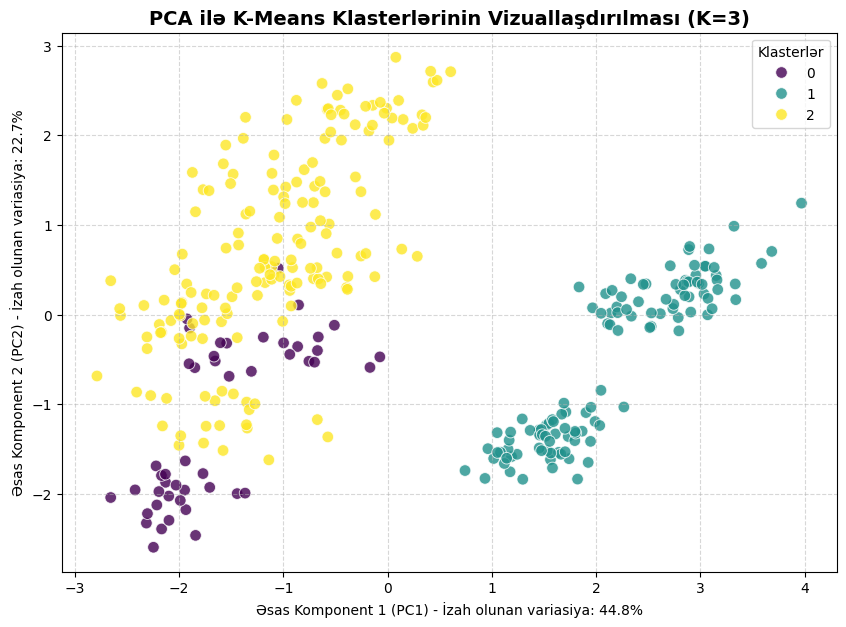

In [94]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    x=pc1, y=pc2,
    hue='Cluster',
    palette='viridis',
    data=df_pca,
    s=70,
    alpha=0.8
)

plt.title('PCA ilə K-Means Klasterlərinin Vizuallaşdırılması (K=3)', fontsize=14, fontweight='bold')
plt.xlabel(f'Əsas Komponent 1 (PC1) - İzah olunan variasiya: {pca.explained_variance_ratio_[0]*100:.1f}%')
plt.ylabel(f'Əsas Komponent 2 (PC2) - İzah olunan variasiya: {pca.explained_variance_ratio_[1]*100:.1f}%')
plt.legend(title='Klasterlər', loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

In [95]:
cross_tab = pd.crosstab(df['cluster_label'], df['species'])

print(cross_tab)

species        Adelie  Chinstrap  Gentoo
cluster_label                           
0                  47          0       0
1                   0          0     119
2                  99         68       0


In [96]:
numeric_cols = ['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g', 'cluster_label']

cluster_profile = df[numeric_cols].groupby('cluster_label').mean()

print(cluster_profile)

               culmen_length_mm  culmen_depth_mm  flipper_length_mm  \
cluster_label                                                         
0                     39.038298        18.451064         191.531915   
1                     47.568067        14.996639         217.235294   
2                     42.839521        18.347904         192.029940   

               body_mass_g  
cluster_label               
0              3708.510638  
1              5092.436975  
2              3716.467066  
